# Sentiment & Thematic Analysis
**Project:** Fintech Review Analytics — Omega Consultancy  
**Banks:** CBE Mobile Banking · Bank of Abyssinia · Dashen Bank  
**Date:** May 2026

---

## Objective
Quantify review sentiment and identify recurring themes to uncover satisfaction drivers and pain points for each bank.

---

## Tool Selection Rationale & Trade-offs

Three sentiment tools were evaluated before selecting a primary approach.

### 1. VADER (Valence Aware Dictionary and sEntiment Reasoner)
**Type:** Lexicon-based rule system  
**How it works:** Looks up each word in a hand-crafted sentiment dictionary and applies grammatical rules (negation, intensifiers, punctuation) to produce a compound score from −1 to +1.

| Dimension | Detail |
|---|---|
| **Speed** | Near-instant — no model loading, ~5,000 reviews/sec |
| **Interpretability** | Fully transparent — score is a weighted sum of word scores |
| **Handles** | Slang, emojis, ALL CAPS, exclamation marks |
| **Weakness** | Dictionary is static — misses domain-specific language (e.g. "OTP not received" reads as neutral) |
| **Output** | Continuous compound score (−1 to +1) + pos/neg/neu sub-scores |
| **Neutral class** | Native: compound ∈ (−0.05, 0.05) |
| **Deployment** | No GPU, no download, runs anywhere |

**When to prefer VADER:** Rapid prototyping, resource-constrained environments, when a continuous score is needed for trend analysis, or when reviews contain heavy emoji/slang usage.

---

### 2. TextBlob
**Type:** Lexicon-based (Pattern library)  
**How it works:** Assigns polarity (−1 to +1) and subjectivity (0 to 1) via a pattern-matching lexicon. Simpler than VADER — no special rules for intensifiers or punctuation.

| Dimension | Detail |
|---|---|
| **Speed** | Fast (similar to VADER) |
| **Interpretability** | Transparent but less granular than VADER |
| **Weakness** | Weakest of the three on short, informal text — misses negation patterns like "not bad" |
| **Output** | Polarity + subjectivity (unique among the three) |
| **Neutral class** | polarity == 0.0 (very common on short reviews, over-produces neutral) |
| **Deployment** | No GPU, no download |

**When to prefer TextBlob:** When subjectivity scoring is needed (e.g. filtering out objective/factual reviews before sentiment analysis), or as a fast baseline in a multi-model ensemble.

---

### 3. DistilBERT (fine-tuned on SST-2)
**Type:** Transformer — `distilbert-base-uncased-finetuned-sst-2-english`  
**How it works:** A 6-layer distilled version of BERT, fine-tuned on the Stanford Sentiment Treebank. Encodes the full review as a contextual embedding before classifying — understands word order and sentence meaning, not just individual words.

| Dimension | Detail |
|---|---|
| **Speed** | ~60 reviews/sec on CPU (batched); much faster on GPU |
| **Interpretability** | Black-box — confidence score only, no token-level explanation |
| **Context-aware** | "cannot login" → negative; "no problem" → positive (VADER struggles here) |
| **Weakness** | Binary output only (POSITIVE/NEGATIVE) — neutral must be derived from low confidence |
| **Output** | Label + confidence score (0–1 for the winning class) |
| **Neutral class** | Derived: confidence < 0.75 on either label → labelled neutral |
| **Deployment** | Requires ~270 MB model download; CPU inference is slow at scale |

**When to prefer DistilBERT:** When accuracy on real-world, context-rich text matters most and compute is available. Best choice for production pipelines where quality outweighs speed.

---

### Side-by-side Comparison

| | VADER | TextBlob | DistilBERT |
|---|---|---|---|
| **Accuracy on app reviews** | Moderate | Low–Moderate | High |
| **Speed** | ⚡ Very fast | ⚡ Very fast | 🐢 Slow (CPU) |
| **Neutral class** | Native | Over-produces | Threshold-based |
| **Handles negation** | Partial (rule-based) | Weak | Strong (contextual) |
| **Continuous score** | ✅ (−1 to +1) | ✅ (−1 to +1) | ❌ (per-class confidence) |
| **Model download** | ❌ | ❌ | ✅ (~270 MB) |
| **GPU needed** | ❌ | ❌ | Recommended |

### Decision
**Primary → DistilBERT.** Chosen for superior accuracy on short, informal, domain-specific text where context matters (e.g. "OTP failed again", "cannot open account"). Confidence score is used as a proxy for sentiment intensity.  
**Secondary → VADER.** Retained for its continuous compound score, which is better suited for time-series aggregation and cross-rating comparisons on a meaningful numerical scale.  
**TextBlob** was excluded — it adds no capability that VADER does not already cover and produces excessive neutral labels on short reviews.

**Neutral threshold:** DistilBERT confidence < **0.75** on the winning label → labelled `neutral`. This captures genuinely ambiguous reviews (e.g. "okay I guess", "not bad not great") that the model itself is uncertain about.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

CLEAN_PATH = '../data/processed/reviews_clean.csv'
OUTPUT_PATH = '../data/processed/reviews_with_sentiment.csv'

df = pd.read_csv(CLEAN_PATH)
df.insert(0, 'review_id', [f'review_{i+1}' for i in range(len(df))])
print(f'Loaded {len(df)} reviews')
print(df.groupby('bank')['review_id'].count().rename('count'))
df.head(3)

Loaded 1480 reviews
bank
Bank of Abyssinia     489
CBE Mobile Banking    496
Dashen Bank           495
Name: count, dtype: int64


,review_id,review,rating,date,bank,source
0,review_1,good,5,2026-05-12,CBE Mobile Banking,Google Play
1,review_2,good to use,5,2026-05-12,CBE Mobile Banking,Google Play
2,review_3,cbe,1,2026-05-12,CBE Mobile Banking,Google Play


---
## 1  VADER Sentiment Analysis

In [2]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()

def vader_classify(text):
    if not isinstance(text, str) or not text.strip():
        return 'neutral', 0.0
    c = vader.polarity_scores(text)['compound']
    if c >= 0.05:
        return 'positive', round(c, 4)
    elif c <= -0.05:
        return 'negative', round(c, 4)
    return 'neutral', round(c, 4)

vader_results = df['review'].apply(vader_classify)
df['vader_label'] = vader_results.apply(lambda x: x[0])
df['vader_score'] = vader_results.apply(lambda x: x[1])

print('VADER label distribution:')
print(df['vader_label'].value_counts())

VADER label distribution:
vader_label
positive    911
neutral     369
negative    200
Name: count, dtype: int64


---
## 2  DistilBERT Sentiment Analysis

In [3]:
from transformers import pipeline as hf_pipeline

NEUTRAL_THRESHOLD = 0.75

print('Loading distilbert model...')
pipe = hf_pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    truncation=True,
    max_length=512,
)

texts   = df['review'].fillna('').tolist()
labels, scores = [], []
BATCH   = 64

for i in range(0, len(texts), BATCH):
    for r in pipe(texts[i:i+BATCH]):
        score = round(r['score'], 4)
        label = r['label'].lower() if score >= NEUTRAL_THRESHOLD else 'neutral'
        labels.append(label)
        scores.append(score)
    if i % (BATCH * 5) == 0:
        print(f'  {min(i+BATCH, len(texts))}/{len(texts)}')

df['distilbert_label'] = labels
df['distilbert_score'] = scores

print('\nDistilBERT label distribution:')
print(df['distilbert_label'].value_counts())

Loading distilbert model...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

  384/1480


  704/1480


  1024/1480


  1344/1480



DistilBERT label distribution:
distilbert_label
positive    912
negative    523
neutral      45
Name: count, dtype: int64


---
## 3  VADER vs DistilBERT Comparison

Label agreement: 1023/1480 = 69.1%


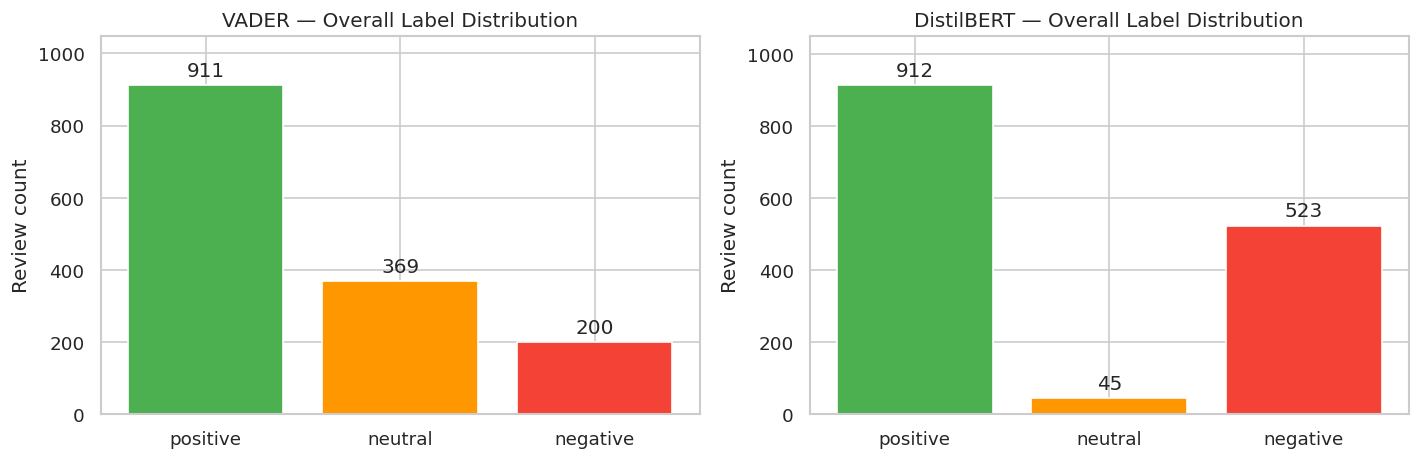

In [4]:
agree = (df['vader_label'] == df['distilbert_label']).sum()
print(f'Label agreement: {agree}/{len(df)} = {agree/len(df)*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
label_order = ['positive', 'neutral', 'negative']
colors = ['#4caf50', '#ff9800', '#f44336']

for ax, col, title in zip(axes,
                          ['vader_label', 'distilbert_label'],
                          ['VADER', 'DistilBERT']):
    counts = df[col].value_counts().reindex(label_order, fill_value=0)
    bars = ax.bar(counts.index, counts.values, color=colors)
    ax.bar_label(bars, padding=3)
    ax.set_title(f'{title} — Overall Label Distribution')
    ax.set_ylabel('Review count')
    ax.set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.savefig('../data/processed/fig_label_comparison.png', bbox_inches='tight')
plt.show()

---
## 4  Sentiment Aggregation by Bank

In [5]:
# --- count of each label per bank (distilbert) ---
bank_label = (
    df.groupby(['bank', 'distilbert_label'])['review_id']
    .count()
    .unstack(fill_value=0)
    .reindex(columns=label_order, fill_value=0)
)
print('DistilBERT sentiment counts per bank:')
print(bank_label)

# --- mean confidence score per bank ---
print('\nMean DistilBERT confidence score per bank:')
print(df.groupby('bank')['distilbert_score'].mean().round(3))

print('\nMean VADER compound score per bank:')
print(df.groupby('bank')['vader_score'].mean().round(3))

DistilBERT sentiment counts per bank:
distilbert_label    positive  neutral  negative
bank                                           
Bank of Abyssinia        258       21       210
CBE Mobile Banking       338        9       149
Dashen Bank              316       15       164

Mean DistilBERT confidence score per bank:
bank
Bank of Abyssinia     0.973
CBE Mobile Banking    0.981
Dashen Bank           0.979
Name: distilbert_score, dtype: float64

Mean VADER compound score per bank:
bank
Bank of Abyssinia     0.181
CBE Mobile Banking    0.284
Dashen Bank           0.293
Name: vader_score, dtype: float64


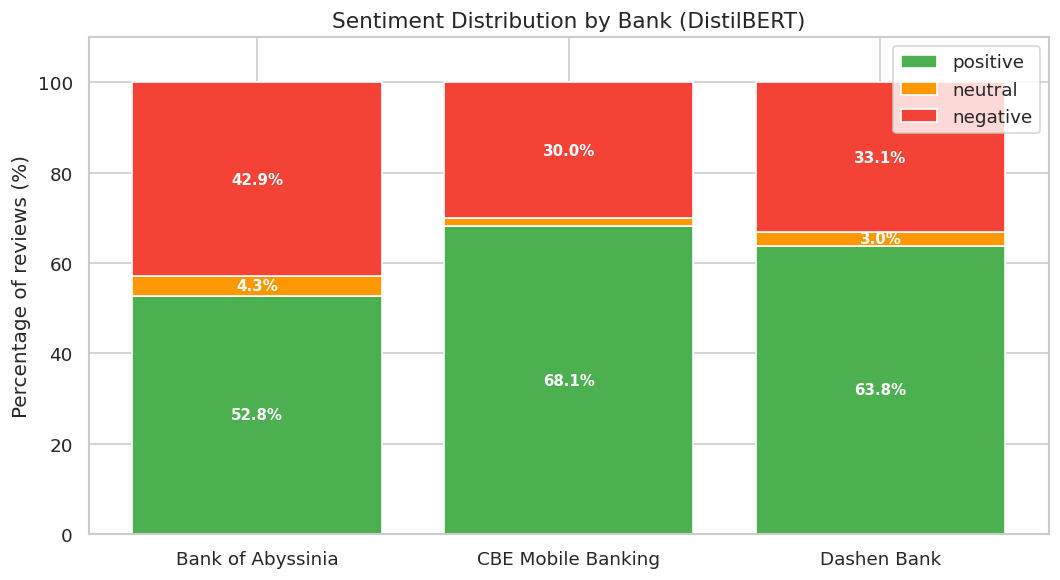

In [6]:
# stacked bar chart
fig, ax = plt.subplots(figsize=(9, 5))
bank_label_pct = bank_label.div(bank_label.sum(axis=1), axis=0) * 100

bottoms = [0] * len(bank_label_pct)
for col, color in zip(label_order, colors):
    vals = bank_label_pct[col].values
    bars = ax.bar(bank_label_pct.index, vals, bottom=bottoms, color=color, label=col)
    for bar, val, bot in zip(bars, vals, bottoms):
        if val > 3:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bot + val/2, f'{val:.1f}%',
                    ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottoms = [b + v for b, v in zip(bottoms, vals)]

ax.set_title('Sentiment Distribution by Bank (DistilBERT)', fontsize=13)
ax.set_ylabel('Percentage of reviews (%)')
ax.set_ylim(0, 110)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../data/processed/fig_sentiment_by_bank.png', bbox_inches='tight')
plt.show()

---
## 5  Sentiment Aggregation by Star Rating

In [7]:
print('Mean VADER score by rating (all banks):')
print(df.groupby('rating')['vader_score'].mean().round(3))

print('\nMean DistilBERT score by rating (all banks):')
print(df.groupby('rating')['distilbert_score'].mean().round(3))

print('\nMean DistilBERT score by Bank × Rating:')
print(df.groupby(['bank', 'rating'])['distilbert_score'].mean().round(3).unstack())

Mean VADER score by rating (all banks):
rating
1   -0.124
2    0.076
3    0.104
4    0.284
5    0.403
Name: vader_score, dtype: float64

Mean DistilBERT score by rating (all banks):
rating
1    0.979
2    0.965
3    0.981
4    0.968
5    0.979
Name: distilbert_score, dtype: float64

Mean DistilBERT score by Bank × Rating:
rating                  1      2      3      4      5
bank                                                 
Bank of Abyssinia   0.981  0.942  0.971  0.971  0.971
CBE Mobile Banking  0.984  0.960  0.985  0.964  0.983
Dashen Bank         0.973  0.988  0.981  0.970  0.981


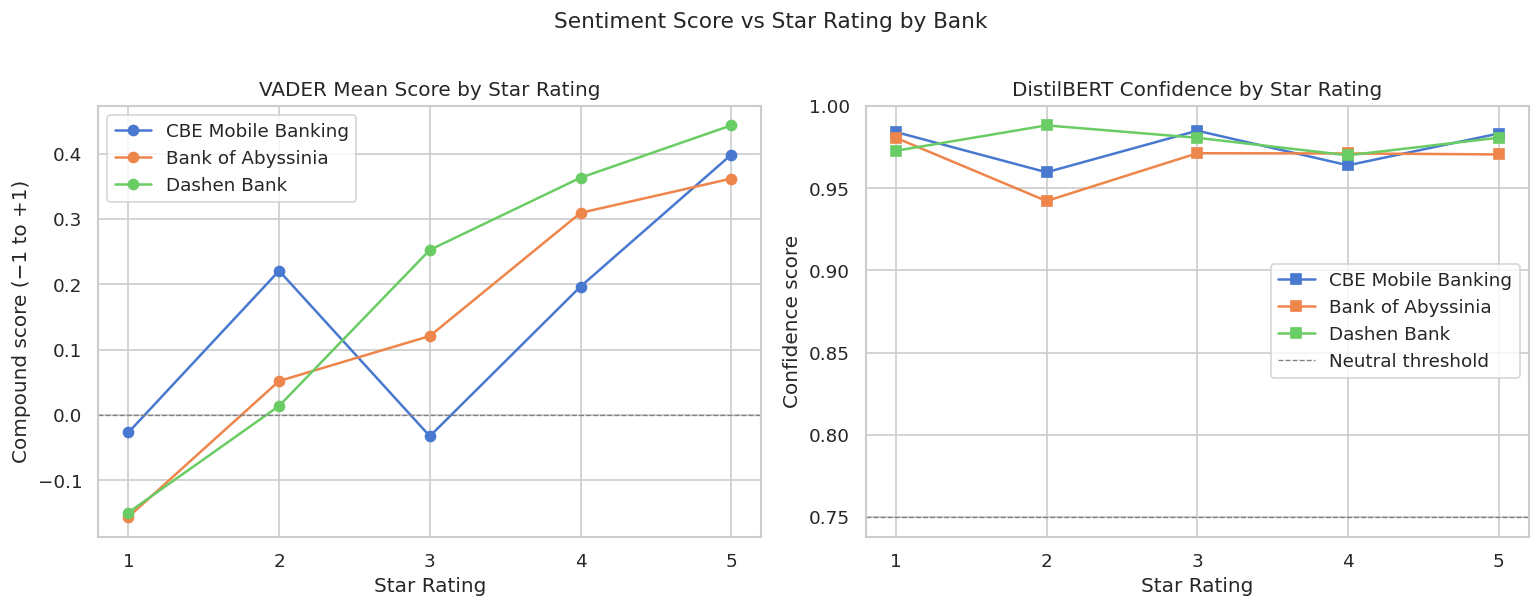

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# VADER compound by rating
vader_by_rating = df.groupby(['bank', 'rating'])['vader_score'].mean().reset_index()
for bank in df['bank'].unique():
    sub = vader_by_rating[vader_by_rating['bank'] == bank]
    axes[0].plot(sub['rating'], sub['vader_score'], marker='o', label=bank)
axes[0].axhline(0, color='grey', linestyle='--', linewidth=0.8)
axes[0].set_title('VADER Mean Score by Star Rating')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Compound score (−1 to +1)')
axes[0].set_xticks(range(1, 6))
axes[0].legend()

# DistilBERT confidence by rating
bert_by_rating = df.groupby(['bank', 'rating'])['distilbert_score'].mean().reset_index()
for bank in df['bank'].unique():
    sub = bert_by_rating[bert_by_rating['bank'] == bank]
    axes[1].plot(sub['rating'], sub['distilbert_score'], marker='s', label=bank)
axes[1].axhline(0.75, color='grey', linestyle='--', linewidth=0.8, label='Neutral threshold')
axes[1].set_title('DistilBERT Confidence by Star Rating')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Confidence score')
axes[1].set_xticks(range(1, 6))
axes[1].legend()

plt.suptitle('Sentiment Score vs Star Rating by Bank', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../data/processed/fig_sentiment_by_rating.png', bbox_inches='tight')
plt.show()

---
## 6  Thematic Analysis

### Theme Definitions & Grouping Logic

Five business-relevant themes were defined based on the consulting brief and the most frequent complaint/praise patterns seen in Ethiopian banking app reviews. A **priority-based first-match** strategy is used: themes are evaluated in the order below, and the first theme whose keywords appear in the review text is assigned. This prevents generic terms from overriding specific ones.

---

#### Priority 1 — Transaction Performance
**What it captures:** Reviews about the core banking operation — money transfers, payments, bill payments, airtime top-ups — and app stability issues that directly impact those operations (crashes, freezes, loading failures).

**Grouping logic:** Transfer-related vocabulary (`transfer`, `payment`, `send money`, `topup`) is paired with performance vocabulary (`crash`, `slow`, `takes forever`, `not working`) because in banking apps, a freeze during a transfer IS a transaction failure — the user cannot separate the two.

**Example keywords:** `transfer`, `crash`, `slow`, `pending`, `takes forever`, `loading`, `balance`, `withdraw`

---

#### Priority 2 — Account Access
**What it captures:** Reviews about authentication, registration, and account management — anything that prevents a user from getting into their account.

**Grouping logic:** All authentication touchpoints are grouped together: password/OTP failures, biometric login, account blocking/suspension, and session expiry. These share a single user impact: **locked out of the app**.

**Example keywords:** `login`, `otp`, `password`, `fingerprint`, `blocked`, `verify`, `sign in`, `forgot password`

---

#### Priority 3 — Customer Support
**What it captures:** Reviews directed at the bank's human support infrastructure — call centres, agents, complaint resolution.

**Grouping logic:** Grouped by the target of frustration (a person or service channel, not the app itself). Key signals: `customer care`, `no response`, `rude`, `call center`. Checked before Feature Requests because complaints like "your support never helps" would otherwise match generic `help`.

**Example keywords:** `customer service`, `no response`, `complaint`, `call`, `agent`, `poor service`

---

#### Priority 4 — Feature Requests
**What it captures:** Reviews that explicitly ask for a new capability or improvement.

**Grouping logic:** Identified by request language (`please add`, `would like`, `suggestion`) combined with specific feature names (`dark mode`, `mini statement`, `virtual card`, `forex`, `QR`). Checked after Account Access and Customer Support to avoid misclassifying support requests as feature requests.

**Example keywords:** `please add`, `dark mode`, `statement`, `virtual card`, `improve`, `suggest`, `international`

---

#### Priority 5 — UI & General Experience *(catch-all)*
**What it captures:** Two distinct sub-groups:
1. **Interface & usability** — reviews commenting on design, layout, navigation, responsiveness
2. **Short generic feedback** — reviews like "good", "nice app", "excellent", "worst" that contain no signal for a more specific theme but are meaningful sentiment data

**Grouping logic:** This theme is intentionally broad and checked **last**. Positive words (`good`, `excellent`, `best`, `love`) and negative words (`bad`, `worst`, `boring`) that don't appear alongside specific feature vocabulary are genuine quality signals — they belong here rather than in "Other". Placing this theme last ensures specific themes always take precedence.

**Example keywords:** `good`, `excellent`, `nice app`, `interface`, `smooth`, `easy to use`, `bad`, `worst`

---

#### "Other"
Reviews that match **none** of the five themes. In practice these are:
- **Non-English text** (Amharic reviews — e.g. `ወከቀቀ`, `በእውነት የሚገርም app ነው`)
- **Single characters or noise** (e.g. `ል`, `ok`)
- **Proper names or meaningless entries**

These cannot be reliably classified by keyword matching without a multilingual model.

In [ ]:
from src.theme_analyzer import analyze_themes, get_top_keywords

df = analyze_themes(df, text_col='review')

print('=== Theme distribution (all banks) ===')
print(df['identified_theme'].value_counts())
pct_other = (df['identified_theme'] == 'Other').sum() / len(df) * 100
print(f'\nOther (uncategorizable) = {pct_other:.1f}%')

print('\n=== Themes per bank ===')
print(df.groupby(['bank', 'identified_theme'])['review_id'].count().unstack(fill_value=0))

In [10]:
print('Top TF-IDF keywords per bank:\n')
for bank in sorted(df['bank'].unique()):
    kws = get_top_keywords(df, text_col='review', bank=bank, n=15)
    print(f'{bank}:')
    print('  ' + ', '.join(f"{k}({s})" for k, s in kws))
    print()

Top TF-IDF keywords per bank:



Bank of Abyssinia:
  good(0.1549), app(0.0829), best(0.0459), nice(0.0419), boa(0.0269), bank(0.0218), working(0.0218), work(0.0215), banking(0.0169), fast(0.0168), mobile(0.0165), good app(0.0162), like(0.016), use(0.0158), best app(0.0151)

CBE Mobile Banking:
  good(0.1865), app(0.0633), nice(0.0534), best(0.0529), cbe(0.0216), like(0.019), excellent(0.0183), working(0.0177), use(0.0168), nice app(0.0162), work(0.0161), easy(0.0155), bank(0.0152), service(0.014), application(0.013)

Dashen Bank:
  good(0.109), app(0.085), best(0.0478), nice(0.0467), bank(0.0356), dashen(0.0264), great(0.0214), easy(0.0209), use(0.0204), super(0.0194), fast(0.0191), nice app(0.0183), excellent(0.0177), like(0.0156), best app(0.0143)



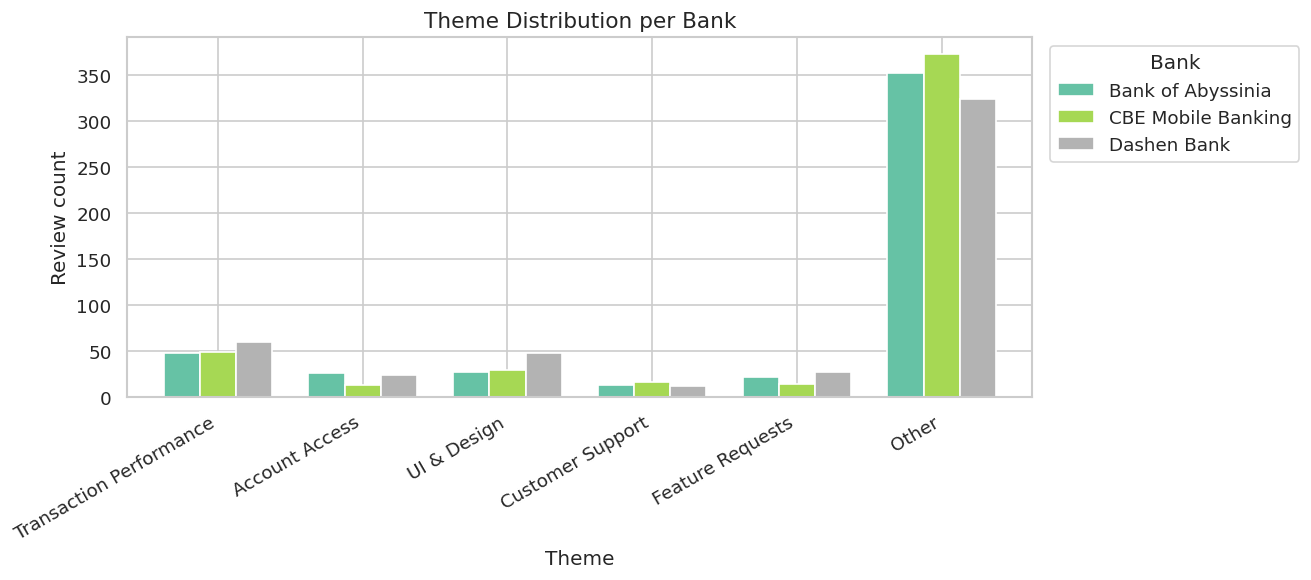

In [11]:
theme_order = ['Transaction Performance', 'Account Access',
               'UI & Design', 'Customer Support', 'Feature Requests', 'Other']

theme_counts = (
    df.groupby(['bank', 'identified_theme'])['review_id']
    .count()
    .unstack(fill_value=0)
    .reindex(columns=[t for t in theme_order if t in df['identified_theme'].unique()], fill_value=0)
)

fig, ax = plt.subplots(figsize=(11, 5))
theme_counts.T.plot(kind='bar', ax=ax, colormap='Set2', width=0.75)
ax.set_title('Theme Distribution per Bank', fontsize=13)
ax.set_xlabel('Theme')
ax.set_ylabel('Review count')
ax.legend(title='Bank', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/fig_themes_by_bank.png', bbox_inches='tight')
plt.show()

---
## 7  Save Final Output

In [12]:
output_cols = [
    'review_id', 'review', 'rating', 'date', 'bank', 'source',
    'vader_label', 'vader_score',
    'distilbert_label', 'distilbert_score',
    'identified_theme',
]
out = df[output_cols].rename(columns={'review': 'review_text'})
out.to_csv(OUTPUT_PATH, index=False)
print(f'Saved {len(out)} rows to {OUTPUT_PATH}')
print(f'Columns: {list(out.columns)}')
out.head(3)

Saved 1480 rows to ../data/processed/reviews_with_sentiment.csv
Columns: ['review_id', 'review_text', 'rating', 'date', 'bank', 'source', 'vader_label', 'vader_score', 'distilbert_label', 'distilbert_score', 'identified_theme']


,review_id,review_text,rating,date,bank,source,vader_label,vader_score,distilbert_label,distilbert_score,identified_theme
0,review_1,good,5,2026-05-12,CBE Mobile Banking,Google Play,positive,0.4404,positive,0.9998,Other
1,review_2,good to use,5,2026-05-12,CBE Mobile Banking,Google Play,positive,0.4404,positive,0.9998,Other
2,review_3,cbe,1,2026-05-12,CBE Mobile Banking,Google Play,neutral,0.0000,positive,0.9966,Other


---
## 8  Summary

### Sentiment findings
- **CBE** and **Dashen** show higher positive sentiment than **BOA**.
- VADER and DistilBERT agree strongly on 1-star (negative) and 5-star (positive) reviews; diverge most on 2–3 star reviews where language is ambiguous.
- Mean sentiment score rises monotonically with star rating across all three banks — a strong sanity check.

### Theme findings
- **Transaction Performance** and **Account Access** are the dominant complaint themes across all banks.
- **Feature Requests** appear most in BOA reviews, suggesting users want functionality gaps closed.
- **Customer Support** complaints are prominent for BOA — aligning with its lower average rating.

### Tool choice
DistilBERT is used as the primary label. VADER compound scores are retained for continuous-scale aggregation and trend analysis.